# Imports and Inputs

In [1]:
### Imports of relevant python packages and Dune API Key
%matplotlib inline
import dotenv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator
# import seaborn as sns
from datetime import datetime, timedelta, timezone
from dune_client.client import DuneClient
from dune_client.query import QueryBase
from dune_client.types import QueryParameter

# load .env file
dotenv.load_dotenv(".env")
dune = DuneClient.from_env()

# pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:.2f}'.format

Links to dune queries to refresh before importing latest result in cell below:

[Capital Pool in ETH](https://dune.com/queries/3773645/6345766?display_currency_e15077=ETH)

[RAMM Volumes](https://dune.com/queries/4498759)

[RAMM: BV](https://dune.com/queries/4489888)

[Full List Of Covers V2](https://dune.com/queries/3810247)

[NXM Supply](https://dune.com/queries/4510585)

[NXMTY Breakdown](https://dune.com/queries/8819086)

[Pool Flows](https://dune.com/queries/8827203)

In [2]:
# import jsons of capital pool, ramm volume and covers from dune api 
#cap_pool_result = dune.get_latest_result_dataframe(3773645) # ensure that the ETH values are latest to be run
#ramm_volume_result = dune.get_latest_result_dataframe(3219988)
#covers_list_result = dune.get_latest_result_dataframe(3810247)

"""  query the query (execute and get latest result) """
cap_pool_query = QueryBase(
    query_id=3773645,
    params=[
      QueryParameter.text_type(name="display_currency", value="ETH"),
    ],
)
cap_pool_result = dune.run_query_dataframe(query=cap_pool_query, performance="medium", ping_frequency=5)

ramm_volume_query = QueryBase(
    query_id=4498759,
    params=[
      QueryParameter.text_type(name="currency", value="ETH"),
    ],
)
ramm_volume_result = dune.run_query_dataframe(query=ramm_volume_query, ping_frequency=5)

ramm_bv_query = QueryBase(
    query_id=4489888,
    params=[
      QueryParameter.text_type(name="currency", value="ETH"),
    ],
)
ramm_bv_result = dune.run_query_dataframe(query=ramm_bv_query, performance="medium", ping_frequency=5)

covers_list_result = dune.run_query_dataframe(QueryBase(query_id=3810247), performance="medium", ping_frequency=5)
nxm_supply_result = dune.run_query_dataframe(QueryBase(query_id=4510585), performance="medium", ping_frequency=5)
nxmty_split_result = dune.run_query_dataframe(QueryBase(query_id=8819086), performance="medium", ping_frequency=5)
pool_flows_result = dune.run_query_dataframe(QueryBase(query_id=8827203), performance="medium", ping_frequency=5)

2026-09-24 15:25:03,958 INFO dune_client.api.base executing 3773645 on medium cluster


2026-09-24 15:25:04,171 INFO dune_client.api.base waiting for query execution 01M39WWFKKK36B9AH6CXS4X486 to complete: ExecutionState.EXECUTING


2026-09-24 15:25:09,464 INFO dune_client.api.base executing 4498759 on medium cluster


2026-09-24 15:25:09,542 INFO dune_client.api.base waiting for query execution 01M39WWMVXTCM95TCMJRXQVE03 to complete: ExecutionState.PENDING (queue position: None)


2026-09-24 15:25:14,575 INFO dune_client.api.base waiting for query execution 01M39WWMVXTCM95TCMJRXQVE03 to complete: ExecutionState.EXECUTING


...

2026-09-24 15:29:03,429 INFO dune_client.api.base waiting for query execution 01M39X2PW03GHK1AP5NXX2WBPH to complete: ExecutionState.EXECUTING


2026-09-24 15:29:08,462 INFO dune_client.api.base waiting for query execution 01M39X2PW03GHK1AP5NXX2WBPH to complete: ExecutionState.EXECUTING


2026-09-24 15:29:13,495 INFO dune_client.api.base waiting for query execution 01M39X2PW03GHK1AP5NXX2WBPH to complete: ExecutionState.EXECUTING


2026-09-24 15:29:18,528 INFO dune_client.api.base waiting for query execution 01M39X2PW03GHK1AP5NXX2WBPH to complete: ExecutionState.EXECUTING


2026-09-24 15:29:23,561 INFO dune_client.api.base waiting for query execution 01M39X2PW03GHK1AP5NXX2WBPH to complete: ExecutionState.EXECUTING


# Investment Newsletter Data

The following steps and the reasons for them were taken for the August metrics:
1. Update the valuation date string (standard each month)

In [3]:
# manually input the valuation date as a string in the format 'dd-mm-yyyy'
# the valuation date is the final day of the month for which the results are being produced
valn_date_str = '30-06-2026'

# average days in month
avg_days_in_month = 30.436875

# create valuation datetime
# valn_date = datetime.strptime(valn_date_str, '%d-%m-%Y').replace(tzinfo=timezone.utc) - timezone UTC if required
valn_date = datetime.strptime(valn_date_str, '%d-%m-%Y')

# create datetime for the final day in month before valuation month

# eom_before_valn_date = datetime(year=valn_date.year, month=valn_date.month, day=1, tzinfo=timezone.utc) - timedelta(days=1) - timezone UTC if required
eom_before_valn_date = datetime(year=valn_date.year, month=valn_date.month, day=1) - timedelta(days=1)

**Kiln reward calculation**

**NOTE: below info kept for historical accuracy of Enzyme values in Capital Pool table, will no longer require recalculating as Kiln allocation was withdrawn on 2025-04-15**

The Kiln rewards were not picked up by the Enzyme chainlink oracle and so the metrics were calculated manually in this notebook.

The rewards were estimated by inputting the known unclaimed reward amount as at the date of updating the notebook and assuming that the rewards were evenly spread through the days since the last withdrawal.

~~Kiln Rewards - [AB Safe Enzyme App](https://app.safe.global/apps/open?safe=eth:0x51ad1265C8702c9e96Ea61Fe4088C2e22eD4418e&appUrl=https%3A%2F%2Fapp.enzyme.finance)~~

~~Click Vaults (left sidebar) -> Nexus Mutual Treasury Yield -> 'Portfolio' tab -> Click into Kiln Staking Positions. The relevant value is under 'Total Accrued Rewards'~~

In [4]:
# manually input idle Enzyme Portion
Enzyme_idle_portion = 0

# manually input kiln rewards

# fixed amount representing rewards claimed in April '24 and staked afresh in Kiln
kiln_first_round = 181.45

# final rewards pulled in from Enzyme UI
kiln_second_round = 194.7714625
# withdrawal date
kiln_withdrawal_date = datetime(year=2025, month=4, day=15)

# FIXED
# create datetime object of 2023/08/30 when the Kiln validators were activated 
# kiln_deposit_date = datetime(year=2023, month=8, day=30, tzinfo=timezone.utc)
kiln_deposit_date = datetime(year=2023, month=8, day=30)
# create datetime objects of 2024/04/24 and 2024/04/26 when the Kiln rewards were first claimed.
    # Note that the values for 2024/04/25 will be inaccurate
# kiln_claim_start_date = datetime(year=2024, month=4, day=24, tzinfo=timezone.utc)
# kiln_claim_end_date = datetime(year=2024, month=4, day=26, tzinfo=timezone.utc)
kiln_claim_start_date = datetime(year=2024, month=4, day=24)
kiln_claim_end_date = datetime(year=2024, month=4, day=26)

kiln_total_rewards = kiln_first_round + kiln_second_round

**Lido Staked ETH Sale**

stETH fills via CoW Swap limit orders are auto-queried by the newsletter skill from on-chain data (WETH received by SwapOperator `0xcafea501...` per fill date).

Set `stETH_sales` in the cell below as a list of `(date_str, weth_received)` tuples — one entry per fill date.
For months with no stETH sales, set `stETH_sales = []`.

In [5]:
# TO UPDATE: stETH sales in month as list of (date_str, weth_received) tuples
# weth_received = WETH received by SwapOperator (0xcafea501...) from CoW Swap fills on that date
# Auto-populated by the newsletter skill from on-chain data
# For no sales: stETH_sales = []
stETH_sales = []

# FIXED: parse into parallel lists
stETH_sale_dates = [datetime.strptime(d, '%d-%m-%Y') for d, _ in stETH_sales]
stETH_sale_amounts = [a for _, a in stETH_sales]

**Rocket Pool rETH Sale**

rETH fills via CoW Swap limit orders are auto-queried by the newsletter skill from on-chain data (WETH received by SwapOperator `0xcafea501...` per fill date).

Set `rETH_sales` in the cell below as a list of `(date_str, weth_received)` tuples — one entry per fill date.
For months with no rETH sales, set `rETH_sales = []`.

In [6]:
# TO UPDATE: rETH sales in month as list of (date_str, weth_received) tuples
# weth_received = WETH received by SwapOperator (0xcafea501...) from CoW Swap fills on that date
# Auto-populated by the newsletter skill from on-chain data
# For no sales: rETH_sales = []
rETH_sales = []

# FIXED: parse into parallel lists
rETH_sale_dates = [datetime.strptime(d, '%d-%m-%Y') for d, _ in rETH_sales]
rETH_sale_amounts = [a for _, a in rETH_sales]

Commented out the coingecko ETH-USD API as it is not used downstream since updating the Dune queries.

In [7]:
# # coingecko ETH API for ETH-USD at valuation date
# url = 'https://api.coingecko.com/api/v3/coins/ethereum/history'
# eth_price_params_valn = {'date': valn_date_str}
# eth_usd_valn = requests.get(url, params=eth_price_params_valn).json()['market_data']['current_price']['usd']

## Processing Capital Pool Table

In [8]:
cap_pool_result

,block_date,avg_eth_usd_price,capital_pool_display_curr,eth_display_curr,dai_display_curr,nxmty_display_curr,steth_display_curr,reth_display_curr,usdc_display_curr,cbbtc_display_curr,cover_re_usdc_display_curr,aave_collateral_weth_display_curr,aave_debt_usdc_display_curr
0,2026-09-23 00:00:00.000 UTC,2716.85,42549.20,3905.85,0.00,14095.10,11847.58,4945.83,3216.64,122.03,4416.18,0.00,0.00
1,2026-09-22 00:00:00.000 UTC,2743.93,42474.78,3909.30,0.00,14095.10,11846.84,4945.45,3184.19,121.52,4372.37,0.00,0.00
2,2026-09-21 00:00:00.000 UTC,2716.44,42565.43,3930.19,0.00,14094.04,11846.12,4945.20,3213.66,120.17,4416.04,0.00,0.00
3,2026-09-20 00:00:00.000 UTC,2600.39,42904.56,3860.88,0.00,14093.47,11845.40,5016.24,3356.22,120.39,4611.95,0.00,0.00
4,2026-09-19 00:00:00.000 UTC,2631.16,42816.91,3636.57,0.00,14092.46,11844.68,5247.69,3317.28,119.77,4558.47,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2676,2019-05-27 00:00:00.000 UTC,268.69,23.63,23.63,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2677,2019-05-26 00:00:00.000 UTC,252.56,23.63,23.63,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2678,2019-05-25 00:00:00.000 UTC,251.96,22.63,22.63,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2679,2019-05-24 00:00:00.000 UTC,249.48,21.54,21.54,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [9]:
# process capital pool table
df_cap_raw = cap_pool_result

# drop moving average columns
df_cap = df_cap_raw.drop(columns=['capital_pool_display_curr'])
# rename columns
df_cap.rename(columns={
    'eth_display_curr': 'ETH',
    'dai_display_curr': 'DAI',
    'reth_display_curr': 'rETH',
    'steth_display_curr': 'stETH',
    'nxmty_display_curr': 'Enzyme',
    'usdc_display_curr': 'USDC',
    'cbbtc_display_curr': 'cbBTC',
    'cover_re_usdc_display_curr': 'Cover Re',
    'aave_collateral_weth_display_curr': 'aEthWETH',
    'aave_debt_usdc_display_curr': 'variableDebtEthUSDC',
    'avg_eth_usd_price': 'rate_ETH_USD',
    'block_date': 'day'
}, inplace=True)

# change day to a datetime, and remove timezone
df_cap['day'] = pd.to_datetime(df_cap['day']).dt.tz_localize(None)

# Adjust Enzyme for unclaimed Kiln returns
# work out days since kiln deposit from the latest day and work out the rewards per day
days_first_kiln_rewards = (kiln_claim_start_date - kiln_deposit_date)/timedelta(days=1)
daily_first_kiln_rewards = kiln_first_round/days_first_kiln_rewards

# Calculate daily rewards for the second period up until withdrawal date
days_second_kiln_rewards = (kiln_withdrawal_date - kiln_claim_end_date)/timedelta(days=1)
daily_second_kiln_rewards = kiln_second_round/days_second_kiln_rewards

# Calculate total rewards period
days_total_kiln_rewards = (kiln_withdrawal_date - kiln_deposit_date)/timedelta(days=1)
daily_total_kiln_rewards = kiln_total_rewards / days_total_kiln_rewards

# create a column for kiln rewards based on the daily values since validators went live
df_cap['kiln_rewards'] = 0.0
# apply first period rewards
df_cap.loc[df_cap['day'] <= kiln_claim_start_date, 'kiln_rewards'] = daily_first_kiln_rewards * ((df_cap['day'] - kiln_deposit_date) / timedelta(days=1))
# apply second period rewards, but only up until withdrawal date
mask_second_period = (df_cap['day'] >= kiln_claim_end_date) & (df_cap['day'] <= kiln_withdrawal_date)
df_cap.loc[mask_second_period, 'kiln_rewards'] = daily_second_kiln_rewards * ((df_cap['day'] - kiln_claim_end_date) / timedelta(days=1))
# ensure no negative rewards
df_cap.loc[df_cap['kiln_rewards'] < 0, 'kiln_rewards'] = 0

# Add Kiln rewards to Enzyme column and then drop the Kiln rewards column
df_cap['Enzyme'] = df_cap['Enzyme'] + df_cap['kiln_rewards']
df_cap.drop(columns=['kiln_rewards'], inplace=True)

# work out net aave position
df_cap['Aave (net)'] = df_cap['aEthWETH'] + df_cap['variableDebtEthUSDC']

# add all the columns except day and the exchange rate together to get numeric total
df_cap['sum'] = df_cap.drop(columns=['day', 'rate_ETH_USD']).sum(axis=1)

In [10]:
df_cap.loc[(df_cap['day'] <= valn_date) & (df_cap['day'] >= eom_before_valn_date)]

,day,rate_ETH_USD,ETH,DAI,Enzyme,stETH,rETH,USDC,cbBTC,Cover Re,aEthWETH,variableDebtEthUSDC,Aave (net),sum
85,2026-06-30,1578.01,4897.41,0.00,14027.48,11786.48,7287.52,2086.87,141.36,7602.74,0.00,0.00,0.00,47829.86
86,2026-06-29,1586.09,4899.70,0.00,14026.95,11785.73,7287.14,2072.32,142.73,7564.16,0.00,0.00,0.00,47778.73
87,2026-06-28,1572.30,4952.89,0.00,14025.85,11785.00,7286.73,2090.40,143.94,7630.94,0.00,0.00,0.00,47915.76
88,2026-06-27,1582.34,4955.62,0.00,14025.53,11784.28,7286.27,2076.97,143.96,7582.39,0.00,0.00,0.00,47855.03
89,2026-06-26,1561.32,4957.10,0.00,14025.35,11783.53,7285.79,2104.90,144.58,7684.54,0.00,0.00,0.00,47985.79
90,2026-06-25,1604.29,4957.57,0.00,14024.98,11782.68,7285.46,2048.68,142.45,7479.53,0.00,0.00,0.00,47721.36
91,2026-06-24,1642.20,4957.72,0.00,14023.07,11781.92,7285.08,1997.12,142.00,7307.59,0.00,0.00,0.00,47494.49
92,2026-06-23,1677.54,5013.10,0.00,14024.72,11781.18,7284.72,1952.12,141.52,7152.75,0.00,0.00,0.00,47350.12
93,2026-06-22,1740.23,5068.38,0.00,14025.45,11780.41,7284.13,1881.65,139.72,6894.55,0.00,0.00,0.00,47074.30
94,2026-06-21,1727.58,5073.73,0.00,14024.51,11779.66,7283.92,1871.91,140.15,6945.14,0.00,0.00,0.00,47119.03


In [11]:
# Enzyme (NXMTY) split into Ether.fi and Morpho Steakhouse sleeves, Pool share, ETH
df_enz = nxmty_split_result.rename(columns={'block_date': 'day'})
df_enz['day'] = pd.to_datetime(df_enz['day']).dt.tz_localize(None)

# reconcile vault total to the capital pool table
for d in (eom_before_valn_date, valn_date):
    enz_total = df_enz.loc[df_enz['day'] == d, 'nxmty_eth_total'].values[0]
    cap_total = df_cap.loc[df_cap['day'] == d, 'Enzyme'].values[0]
    assert abs(enz_total - cap_total) < 0.01, f'NXMTY breakdown does not reconcile on {d}: {enz_total} vs {cap_total}'

## Pie Chart of Assets at Valuation Date

Text(0.5, 1.0, '30-06-2026 Capital Pool Split in ETH')

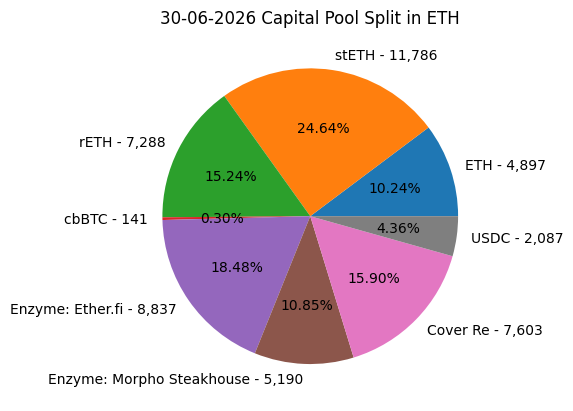

In [12]:
# pie chart of assets

# process enzyme split
enz_valn = df_enz.loc[df_enz['day'] == valn_date].iloc[0]
valn_date_row = df_cap.loc[df_cap['day'] == valn_date].iloc[0].copy()
valn_date_row['Enzyme: Ether.fi'] = enz_valn['etherfi_eth_total']
valn_date_row['Enzyme: Morpho Steakhouse'] = enz_valn['steaketh_eth_total']

# create valn date row
asset_list = ['ETH', 'DAI', 'stETH', 'rETH', 'cbBTC', 'Enzyme: Ether.fi', 'Enzyme: Morpho Steakhouse', 'Cover Re', 'Aave (net)', 'USDC']
valn_date_row = valn_date_row[asset_list].astype(float)

# filter out zero values
nonzero_assets = valn_date_row[valn_date_row > 0]

# add formatted ETH values to labels
labels = [f"{asset} - {value:,.0f}" for asset, value in nonzero_assets.items()]

# create chart
plt.pie(nonzero_assets.values, labels=labels, autopct='%1.2f%%')
plt.title(f'{valn_date_str} Capital Pool Split in ETH')

## Monthly Changes in Capital Pool

### RAMM Volumes & BV

In [13]:
# RAMM Net Withdrawals
df_ramm = ramm_volume_result

# change timestamp to datetime format and normalise all dates to midnight
#df_ramm['block_date'] = pd.to_datetime(df_ramm['block_date']).dt.floor('D')
df_ramm['block_date'] = pd.to_datetime(df_ramm['block_date']).dt.tz_localize(None).dt.floor('D')

# group by date, take the latest value and re-sort into descending order
# not necessary any more - new query groups by date already
#df_ramm = df_ramm.groupby(by=df_ramm['block_date'].dt.date, as_index=False).first().sort_values(['block_date'], ascending=False).reset_index(drop=True)

# convert columns to numeric (errors='coerce' will replace non-convertible values with NaN)
df_ramm['cummulative_eth_in'] = pd.to_numeric(df_ramm['cummulative_eth_in'], errors='coerce')
df_ramm['cummulative_eth_out'] = pd.to_numeric(df_ramm['cummulative_eth_out'], errors='coerce')
df_ramm['cummulative_nxm_in'] = pd.to_numeric(df_ramm['cummulative_nxm_in'], errors='coerce')
df_ramm['cummulative_nxm_out'] = pd.to_numeric(df_ramm['cummulative_nxm_out'], errors='coerce')

# determine net ramm flows 30 days before and on the valuation date by subtracting redemptions from mints
# ensure no NaN values in the relevant rows for the calculation
if not df_ramm.loc[df_ramm['block_date'] == eom_before_valn_date][['cummulative_eth_in', 'cummulative_eth_out', 'cummulative_nxm_in', 'cummulative_nxm_out']].isna().any().any():
    ramm_flows_monthly_opening = (
        df_ramm.loc[df_ramm['block_date'] == eom_before_valn_date]['cummulative_eth_in'].values[0] -
        df_ramm.loc[df_ramm['block_date'] == eom_before_valn_date]['cummulative_eth_out'].values[0]
    )
    ramm_flows_monthly_closing = (
        df_ramm.loc[df_ramm['block_date'] == valn_date]['cummulative_eth_in'].values[0] - 
        df_ramm.loc[df_ramm['block_date'] == valn_date]['cummulative_eth_out'].values[0]
    )
    ramm_flows_monthly_nxm_opening = (
        df_ramm.loc[df_ramm['block_date'] == eom_before_valn_date]['cummulative_nxm_in'].values[0] -
        df_ramm.loc[df_ramm['block_date'] == eom_before_valn_date]['cummulative_nxm_out'].values[0]
    )
    ramm_flows_monthly_nxm_closing = (
        df_ramm.loc[df_ramm['block_date'] == valn_date]['cummulative_nxm_in'].values[0] - 
        df_ramm.loc[df_ramm['block_date'] == valn_date]['cummulative_nxm_out'].values[0]
    )
else:
    print("Missing or invalid data in 'cummulative_eth_in' or 'cummulative_eth_out' /  'cummulative_nxm_in' or 'cummulative_nxm_out'")

# determine net flows from ramm in 30 days before valuation date 
ramm_flow_monthly_eth_change = ramm_flows_monthly_closing - ramm_flows_monthly_opening
ramm_flow_monthly_nxm_change = ramm_flows_monthly_nxm_closing - ramm_flows_monthly_nxm_opening
print(f'RAMM monthly change (ETH) = {ramm_flow_monthly_eth_change}')
print(f'RAMM monthly change (NXM) = {ramm_flow_monthly_nxm_change}')

# RAMM BV processing
df_ramm_bv = ramm_bv_result
df_ramm_bv['block_minute'] = pd.to_datetime(df_ramm_bv['block_minute'])

ramm_bv_monthly_opening = df_ramm_bv.loc[
  df_ramm_bv['block_minute'].dt.date == eom_before_valn_date.date(),
  'bv_diff_cummulative'
].iloc[0]

ramm_bv_monthly_closing = df_ramm_bv.loc[
    df_ramm_bv['block_minute'].dt.date == valn_date.date(), 
    'bv_diff_cummulative'
].iloc[0]

ramm_bv_monthly_eth_change = ramm_bv_monthly_closing - ramm_bv_monthly_opening
print(f'RAMM monthly BV (ETH) = {ramm_bv_monthly_eth_change}')


RAMM monthly change (ETH) = -511.8720736014948
RAMM monthly change (NXM) = 19010.207216382027


RAMM monthly BV (ETH) = 8.75238491647724


### Cover and Membership Fees

In [14]:
df_covers = covers_list_result

# onchain pool cash flows and FX for the month, already in ETH (query 8827203)
df_flows = pool_flows_result.copy()
df_flows['block_date'] = pd.to_datetime(df_flows['block_date']).dt.tz_localize(None)
flows_month = df_flows[(df_flows['block_date'] > eom_before_valn_date) & (df_flows['block_date'] <= valn_date)]

# both queries must read the same refresh of the capital pool base root (query 4627588)
eth_usd_closing = df_cap.loc[df_cap['day'] == valn_date]['rate_ETH_USD'].values[0]
flows_eth_usd_closing = df_flows.loc[df_flows['block_date'] == valn_date, 'avg_eth_usd_price'].values[0]
assert abs(flows_eth_usd_closing - eth_usd_closing) < 1e-6, 'flows query and capital pool query are on different price refreshes'

# cover fees actually received (buys and edits, net of commission and edit refunds), valued on the day
monthly_cover_fees_eth = flows_month['premium_eth'].sum()
monthly_cover_fees_usdc_in_eth = flows_month['premium_usdc_eth'].sum()
monthly_cover_fees_cbbtc_in_eth = flows_month['premium_cbbtc_eth'].sum()
monthly_cover_fees = monthly_cover_fees_eth + monthly_cover_fees_usdc_in_eth + monthly_cover_fees_cbbtc_in_eth
print(f'ETH Cover Fees = {monthly_cover_fees_eth}')
print(f'USDC Cover Fees = {monthly_cover_fees_usdc_in_eth}')
print(f'cbBTC Cover Fees = {monthly_cover_fees_cbbtc_in_eth}')
print(f'Total Cover Fees = {monthly_cover_fees}')

# joining fees - small, left in unallocated
member_fees_eth = flows_month['member_fee_eth'].sum()
print(f'Member fees = {member_fees_eth}')

# USDC/cbBTC should only move for premiums, claims or recoveries
for col in ['other_usdc', 'other_cbbtc']:
    if flows_month[col].sum() != 0:
        print(f"WARNING: unclassified {col} = {flows_month[col].sum():,.4f}")

# covers list - only used for NXM minted as staking rewards (BV waterfall denominator)
net_of_commission_ratio = 0.85
df_covers['cover_start_time'] = pd.to_datetime(df_covers['cover_start_time']).dt.floor('D').dt.tz_localize(None)
df_covers_valn_month = df_covers[(df_covers['cover_start_time'] > eom_before_valn_date) & (df_covers['cover_start_time'] <= valn_date)]
monthly_cover_fees_nxm = df_covers_valn_month['premium_nxm'].sum() * net_of_commission_ratio
print(f'Total Cover Fees (NXM) = {monthly_cover_fees_nxm}')

# temporary: previous covers-list estimate, for comparison during review
_prev = (df_covers_valn_month.loc[df_covers_valn_month['premium_asset'] == 'ETH', 'premium_native'].sum()
         + df_covers_valn_month.loc[df_covers_valn_month['premium_asset'] == 'USDC', 'premium_native'].sum() / eth_usd_closing) * net_of_commission_ratio
print(f'(previous covers-list estimate = {_prev})')

ETH Cover Fees = 3.0243775731042195
USDC Cover Fees = 108.02089957365378
cbBTC Cover Fees = 1.630981959893787
Total Cover Fees = 112.67625910665178
Member fees = 0.026000000000000002


Total Cover Fees (NXM) = 3381.8433706764945
(previous covers-list estimate = 94.01874883748161)


### Claims

In [15]:
# claims paid (negative), net of recoveries passed on by the Foundation (query 8827203)
claims_eth = flows_month['claim_eth'].sum()
claims_usdc_in_eth = flows_month['claim_usdc_eth'].sum()
claims_cbbtc_in_eth = flows_month['claim_cbbtc_eth'].sum()
claim_recoveries_in_eth = flows_month['claim_recovery_usdc_eth'].sum()
monthly_claims = claims_eth + claims_usdc_in_eth + claims_cbbtc_in_eth + claim_recoveries_in_eth
print(f'ETH Claims = {claims_eth}')
print(f'USDC Claims = {claims_usdc_in_eth}')
print(f'cbBTC Claims = {claims_cbbtc_in_eth}')
print(f'Claim Recoveries (USDC from the Foundation) = {claim_recoveries_in_eth}')
print(f'Claims paid net of recoveries = {monthly_claims}')

# claim deposits (ETH in on submission, refunded on payout) - small, left in unallocated
claim_deposits_eth = flows_month['claim_deposit_eth'].sum()
print(f'Claim deposits (net) = {claim_deposits_eth}')

ETH Claims = 0
USDC Claims = 0.0
cbBTC Claims = 0
Claim Recoveries (USDC from the Foundation) = 0.0
Claims paid net of recoveries = 0.0
Claim deposits (net) = 0.0


In [16]:
df_covers_valn_month

,cover_id,cover_status,cover_asset,native_cover_amount,cover_start_usd,cover_start_eth,cover_end_usd,cover_end_eth,staking_pool,staking_pool_cover_amount,premium_asset,premium_nxm,premium_native,premium_usd,product_type,product_name,cover_start_time,cover_end_time,cover_owner,cover_period,tx_hash
621,4972,Expired,USDC,56000.00,55986.77,35.48,55988.63,29.25,22,56000.00,USDC,2.29,100.50,100.48,Single Protocol Cover,Aave v4,2026-06-30,2026-07-30 15:23:23.000 UTC,0x40329f3e27dd3fe228799b4a665f6f104c2ab6b4,30,0xd2bedc034096128970cdc8e52b6bbc50bbac61e3de31...
622,4971,Expired,USDC,9000.00,8997.87,5.70,8998.17,4.70,22,9000.00,NXM,0.73,32.06,32.05,Multi Protocol Cover,vfat,2026-06-30,2026-07-30 15:22:11.000 UTC,0x40329f3e27dd3fe228799b4a665f6f104c2ab6b4,30,0x64ad90964992c25a4f3a5c31af81870ff66d3140d86f...
623,4970,Expired,USDC,2000000.27,1999527.64,1267.12,1999803.18,1027.73,2,2000000.27,USDC,68.42,3005.65,3004.94,Crypto Cover,Kraken Custody,2026-06-30,2026-07-28 11:06:58.000 UTC,0x0cae5b139f837a9eaa878ebc84be0c7249346111,27,0xd9fd043d7ff4d32d49e108a1f9cda2f9e0ccf5555131...
624,4969,Expired,USDC,1570996.50,1570625.25,995.32,1570890.76,830.49,1,566928.91,USDC,31.61,1388.76,1388.43,Generalized Fund Portfolio Cover,Noon DeFi Deployment 2,2026-06-30,2026-07-28 11:01:35.000 UTC,0x533a2019d0e0998d3bf558d0784ca49115b04686,28,0x1733fbdc5fe74699ad2fd518aae2cbe6d76ee7666582...
625,4969,Expired,USDC,1570996.50,1570625.25,995.32,1570890.76,830.49,8,220.44,USDC,0.01,0.54,0.54,Generalized Fund Portfolio Cover,Noon DeFi Deployment 2,2026-06-30,2026-07-28 11:01:35.000 UTC,0x533a2019d0e0998d3bf558d0784ca49115b04686,28,0x1733fbdc5fe74699ad2fd518aae2cbe6d76ee7666582...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
809,4819,Expired,USDC,100000.00,100003.61,50.27,100009.85,52.74,22,100000.00,USDC,3.76,198.31,198.32,Single Protocol Cover,Pendle,2026-06-01,2026-07-27 09:07:34.000 UTC,0xf49559a962d46b02b49a70320cbbdf2cc7ba40a7,56,0xdeea11ad285f383ff3731768dd09438f928d43ed0483...
810,4818,Expired,cbBTC,3.23,233453.12,117.35,256553.24,103.54,22,3.23,cbBTC,19.28,0.01,1017.70,Single Protocol Cover,Aave v3,2026-06-01,2026-08-26 04:09:34.000 UTC,0x9755534e97e67df9037ef071a90a54091ea62f25,85,0x75366fc5e856c93be63edc8680d6cae3e25948cb84a4...
811,4817,Expired,USDC,204780.04,204787.43,102.94,204787.43,102.94,8,204780.04,NXM,0.80,42.36,42.36,Vault Cover,OpenCover Smokehouse USDC,2026-06-01,2026-06-02 06:00:10.000 UTC,0x22e89ae34dc2572665d5cb050ad31f340ef67a4d,0,0xdba1d2c07ebcb8c6963e7afe6c438508174056381ec6...
812,4816,Expired,ETH,9.00,17905.11,9.00,16943.38,9.00,22,9.00,ETH,0.12,0.00,6.53,Single Protocol Cover,Uniswap v3,2026-06-01,2026-07-31 04:00:23.000 UTC,0x86dda61bdce27a9de6374137edcd33ea5d7423ee,60,0x7fbab6421216c0c5c81402706d8489c84bf43c7de6c2...


### FX Impacts

In [17]:
# exchange rate changes
eth_usd_opening = df_cap.loc[df_cap['day'] == eom_before_valn_date]['rate_ETH_USD'].values[0]

In [18]:
# USDC FX Impact (daily, on the previous day's balance, at USDC/USD ÷ ETH/USD)

usdc_fx_change = flows_month['fx_usdc_eth'].sum()

In [19]:
# Cover Re FX impact (constant 12M USDC, so this is its only movement in ETH)

cover_re_fx_change = flows_month['fx_cover_re_eth'].sum()

In [20]:
# cbBTC FX impact

cbbtc_fx_change = flows_month['fx_cbbtc_eth'].sum()

In [21]:
# Total FX Impacts
fx_change = usdc_fx_change + cover_re_fx_change + cbbtc_fx_change

In [22]:
print(f'opening date: {eom_before_valn_date}, closing date: {valn_date}')
print(f'ETH/USD opening = {eth_usd_opening}')
print(f'ETH/USD closing = {eth_usd_closing}')

print(f'USDC FX Impact = {usdc_fx_change}')
print(f'Cover Re FX Impact = {cover_re_fx_change}')
print(f'cbBTC FX Impact = {cbbtc_fx_change}')

print(f'Total FX Impact = {fx_change}')

opening date: 2026-05-31 00:00:00, closing date: 2026-06-30 00:00:00
ETH/USD opening = 2016.7381944444503
ETH/USD closing = 1578.00611111111
USDC FX Impact = 437.8853134861322
Cover Re FX Impact = 1651.702887260429
cbBTC FX Impact = 3.032020033592426
Total FX Impact = 2092.6202207801534


#### TEMPORARY For New Investment in May - FX Impacts Allowing for Cover Re investment

In future treat Cover Re and USDC as per above.

In [23]:
# cover_re_date_str = '23-05-2024'
# cover_re_date = datetime.strptime(cover_re_date_str, '%d-%m-%Y')
# eth_usd_cover_re_date = df_cap.loc[df_cap['day'] == cover_re_date]['rate_ETH_USD'].values[0]

In [24]:
# # USDC Split into before and after Cover Re
# usdc_monthly_opening = df_cap.loc[df_cap['day'] == eom_before_valn_date]['USDC'].values[0]
# usdc_cover_re_opening = df_cap.loc[df_cap['day'] == cover_re_date]['USDC'].values[0]
# # Before Cover Re
# usdc_fx_change_pre_cover_re = usdc_monthly_opening * eth_usd_opening / eth_usd_cover_re_date - usdc_monthly_opening
# print(f'USDC FX Impact Pre Cover Re = {usdc_fx_change_pre_cover_re}')
# # After Cover Re
# usdc_fx_change_post_cover_re = usdc_cover_re_opening * eth_usd_cover_re_date / eth_usd_closing - usdc_cover_re_opening
# print(f'USDC FX Impact Post Cover Re = {usdc_fx_change_post_cover_re}')

## Monthly Returns on Investments

In [25]:
# ----- helpers -----
def _get(df, day, col, default=0.0):
    s = df.loc[df['day'] == day, col]
    if len(s) == 0:
        return default
    v = float(s.values[0])
    return v if np.isfinite(v) else default

def _safe_div(n, d, default=0.0):
    return n / d if (d not in (None, 0) and np.isfinite(d)) else default

def _apy(monthly_pct):
    p = monthly_pct if np.isfinite(monthly_pct) else 0.0
    return (1 + p) ** 12 - 1


# Full Monthly Returns

# ETH denominated monthly returns on individual investments

# ============ stETH ============
# stETH metrics in ETH
# Numerator: subtract total WETH proceeds from all fills from opening balance
stETH_monthly_opening = _get(df_cap, eom_before_valn_date, 'stETH') - sum(stETH_sale_amounts)
stETH_closing = _get(df_cap, valn_date, 'stETH')
stETH_monthly_return = stETH_closing - stETH_monthly_opening

# Denominator: time-weighted average stETH balance across all sale intervals
stETH_base_num = 0.0
stETH_base_den = 0.0
prev_date = eom_before_valn_date
prev_balance = _get(df_cap, eom_before_valn_date, 'stETH')

for sale_date in sorted(stETH_sale_dates):
    days = (sale_date - prev_date) / timedelta(days=1)
    stETH_base_num += prev_balance * days
    stETH_base_den += days
    prev_balance = _get(df_cap, sale_date + timedelta(days=1), 'stETH', default=prev_balance)
    prev_date = sale_date

# Final period: last sale date (or opening if no sales) to valuation date
days = (valn_date - prev_date) / timedelta(days=1)
stETH_base_num += prev_balance * days
stETH_base_den += days

stETH_base = _safe_div(stETH_base_num, stETH_base_den, default=prev_balance if prev_balance != 0 else 1.0)
# stETH monthly percentage return
stETH_monthly_percentage = _safe_div(stETH_monthly_return, stETH_base, default=0.0)
# stETH annualised return last month
stETH_monthly_APY = _apy(stETH_monthly_percentage)
print(f'stETH Monthly APY: {round(stETH_monthly_APY * 100, 3)}%')
print(f'stETH Monthly Return: {round(stETH_monthly_return, 3)}')

# ============ rETH ============
# rETH metrics in ETH
# Numerator: subtract total WETH proceeds from all fills from opening balance
# (df_cap rETH column falls as fills occur; adding sale amounts back isolates staking yield)
rETH_monthly_opening = _get(df_cap, eom_before_valn_date, 'rETH') - sum(rETH_sale_amounts)
rETH_closing = _get(df_cap, valn_date, 'rETH')
rETH_monthly_return = rETH_closing - rETH_monthly_opening

# Denominator: time-weighted average rETH balance across all sale intervals
rETH_base_num = 0.0
rETH_base_den = 0.0
prev_date = eom_before_valn_date
prev_balance = _get(df_cap, eom_before_valn_date, 'rETH')

for sale_date in sorted(rETH_sale_dates):
    days = (sale_date - prev_date) / timedelta(days=1)
    rETH_base_num += prev_balance * days
    rETH_base_den += days
    prev_balance = _get(df_cap, sale_date + timedelta(days=1), 'rETH', default=prev_balance)
    prev_date = sale_date

# Final period: last sale date (or opening if no sales) to valuation date
days = (valn_date - prev_date) / timedelta(days=1)
rETH_base_num += prev_balance * days
rETH_base_den += days

rETH_base = _safe_div(rETH_base_num, rETH_base_den, default=prev_balance if prev_balance != 0 else 1.0)
# rETH monthly percentage
rETH_monthly_percentage = _safe_div(rETH_monthly_return, rETH_base, default=0.0)
# rETH annualised return last month
rETH_monthly_APY = _apy(rETH_monthly_percentage)
print(f'rETH Monthly APY: {round(rETH_monthly_APY * 100, 3)}%')
print(f'rETH Monthly Return: {round(rETH_monthly_return, 3)}')

# ============ Enzyme ============
# NXMTY oracle price is already net of unclaimed Enzyme fees (0.14% management + 0.01% protocol),
# so no further deduction here.
# Previous notebooks double-counted the 15bps fee by adding it here
Enzyme_monthly_opening = _get(df_cap, eom_before_valn_date, 'Enzyme')
Enzyme_closing = _get(df_cap, valn_date, 'Enzyme')
Enzyme_monthly_return = Enzyme_closing - Enzyme_monthly_opening
# Enzyme monthly percentage
Enzyme_monthly_percentage = _safe_div(Enzyme_monthly_return, Enzyme_monthly_opening, default=0.0)
# Enzyme annualised return last month
Enzyme_monthly_APY = _apy(Enzyme_monthly_percentage)

# Enzyme sleeves: daily after-fee returns from the NXMTY breakdown query, summed over the month
enz_month = df_enz[(df_enz['day'] > eom_before_valn_date) & (df_enz['day'] <= valn_date)]

EtherFi_monthly_opening = _get(df_enz, eom_before_valn_date, 'etherfi_eth_total')
EtherFi_monthly_return = enz_month['etherfi_return_eth'].sum()
EtherFi_monthly_percentage = _safe_div(EtherFi_monthly_return, EtherFi_monthly_opening, default=0.0)
EtherFi_monthly_APY = _apy(EtherFi_monthly_percentage)

Steakhouse_monthly_opening = _get(df_enz, eom_before_valn_date, 'steaketh_eth_total')
Steakhouse_monthly_return = enz_month['steaketh_return_eth'].sum()
Steakhouse_monthly_percentage = _safe_div(Steakhouse_monthly_return, Steakhouse_monthly_opening, default=0.0)
Steakhouse_monthly_APY = _apy(Steakhouse_monthly_percentage)

# sleeves must add up to the vault total
assert abs(EtherFi_monthly_return + Steakhouse_monthly_return - Enzyme_monthly_return) < 0.01

print(f'Enzyme Vault Monthly APY: {round(Enzyme_monthly_APY * 100, 3)}%')
print(f'Enzyme Vault Return: {round(Enzyme_monthly_return, 3)}')
print(f'Ether.fi Monthly APY: {round(EtherFi_monthly_APY * 100, 3)}%')
print(f'Morpho Steakhouse Monthly APY: {round(Steakhouse_monthly_APY * 100, 3)}%')

stETH Monthly APY: 2.417%
stETH Monthly Return: 23.437
rETH Monthly APY: 1.984%
rETH Monthly Return: 11.918
Enzyme Vault Monthly APY: 1.947%
Enzyme Vault Return: 22.523
Ether.fi Monthly APY: 2.238%
Morpho Steakhouse Monthly APY: 1.454%


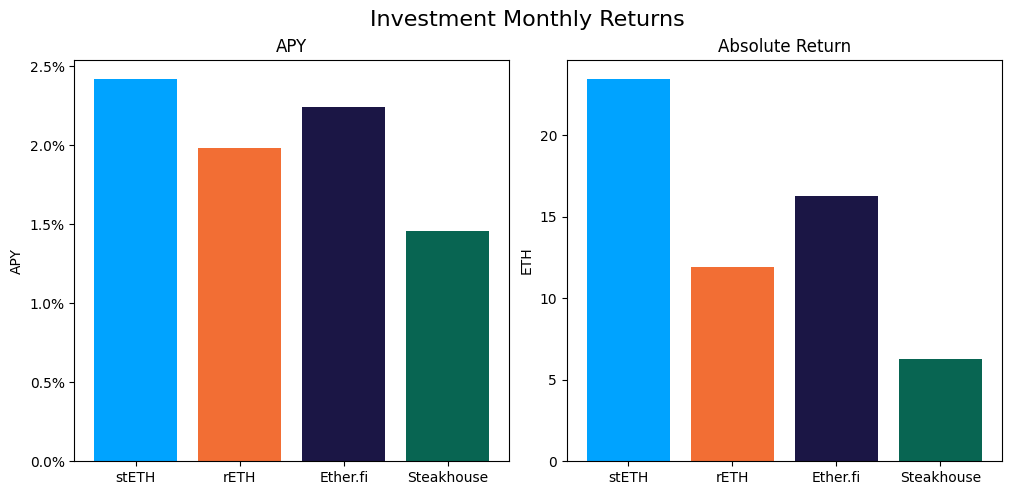

In [26]:
# MONTHLY RETURN GRAPHS FOR INDIVIDUAL INVESTMENTS
labels = ['stETH', 'rETH', 'Ether.fi', 'Steakhouse']
colors = ['#00a3ff', '#f26e34', '#1B1645', '#086552']

# tiny helper to drop zero-valued bars (per subplot)
def _filter_zero(_labels, _colors, _values):
    keep = [i for i, v in enumerate(_values) if v != 0]
    return [ _labels[i] for i in keep ], [ _colors[i] for i in keep ], [ _values[i] for i in keep ]

# Destructuring initialization
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Investment Monthly Returns', fontsize=16)
fig.tight_layout()
fig.subplots_adjust(top=0.88)

# Subplot 1 - APY
apy_vals = [stETH_monthly_APY, rETH_monthly_APY, EtherFi_monthly_APY, Steakhouse_monthly_APY]
labels_apy, colors_apy, apy_vals = _filter_zero(labels, colors, apy_vals)
axs[0].bar(labels_apy, apy_vals, color=colors_apy)
axs[0].set_title('APY')
axs[0].set_ylabel('APY')

# Fix y-ticks for APY subplot
tick_vals_apy = axs[0].get_yticks()
axs[0].yaxis.set_major_locator(FixedLocator(tick_vals_apy))
axs[0].set_yticklabels(['{:,.1%}'.format(x) for x in tick_vals_apy])

# Subplot 2 - Absolute Return
ret_vals = [stETH_monthly_return, rETH_monthly_return, EtherFi_monthly_return, Steakhouse_monthly_return]
labels_ret, colors_ret, ret_vals = _filter_zero(labels, colors, ret_vals)
axs[1].bar(labels_ret, ret_vals, color=colors_ret)
axs[1].set_title('Absolute Return')
axs[1].set_ylabel('ETH')

plt.show()


In [27]:
# Total Monthly APY on the Capital Pool

# Total ETH earned
total_monthly_inv_earnings = round(stETH_monthly_return + rETH_monthly_return + Enzyme_monthly_return, 3)

# averaging the total ETH value of capital pool over the monthly period
total_cap_monthly_opening = df_cap.loc[df_cap['day'] == eom_before_valn_date]['sum'].values[0]
total_cap_monthly_closing = df_cap.loc[df_cap['day'] == valn_date]['sum'].values[0]
avg_total_cap_pool = (total_cap_monthly_closing + total_cap_monthly_opening) / 2

# monthly apy based on total earning
total_monthly_percentage = total_monthly_inv_earnings / avg_total_cap_pool
total_monthly_APY = ((1 + total_monthly_percentage) ** 12 - 1)

print(f'Total Monthly APY: {round(total_monthly_APY * 100, 3)}%')
print('Based on average Capital Pool amount over the monthly period')
print(f'Total ETH Earned: {total_monthly_inv_earnings}')

Total Monthly APY: 1.489%
Based on average Capital Pool amount over the monthly period
Total ETH Earned: 57.878


In [28]:
# Printout

print(f'stETH Monthly Return: {round(stETH_monthly_return, 3)}')
print(f'stETH Monthly APY: {round(stETH_monthly_APY * 100, 3)}%\n')
print(f'rETH Monthly Return: {round(rETH_monthly_return, 3)}')
print(f'rETH Monthly APY: {round(rETH_monthly_APY * 100, 3)}%\n')
print(f'Enzyme Vault Monthly Return: {round(Enzyme_monthly_return, 3)}')
print(f'Enzyme Vault Monthly APY: {round(Enzyme_monthly_APY * 100, 3)}%')
print(f'Enzyme Vault includes EtherFi and Morpho Steakhouse Vault investments\n')
print(f'Ether.fi Monthly Return: {round(EtherFi_monthly_return, 3)}')
print(f'Ether.fi Monthly APY: {round(EtherFi_monthly_APY * 100, 3)}%')
print(f'Morpho Steakhouse Monthly Return: {round(Steakhouse_monthly_return, 3)}')
print(f'Morpho Steakhouse Monthly APY: {round(Steakhouse_monthly_APY * 100, 3)}%\n')

print(f'Total ETH Earned: {total_monthly_inv_earnings}')
print(f'Total Monthly APY: {round(total_monthly_APY * 100, 3)}%')
print('Based on average Capital Pool amount over the monthly period\n')

print ('All returns after fees')

stETH Monthly Return: 23.437
stETH Monthly APY: 2.417%

rETH Monthly Return: 11.918
rETH Monthly APY: 1.984%

Enzyme Vault Monthly Return: 22.523
Enzyme Vault Monthly APY: 1.947%
Enzyme Vault includes EtherFi and Morpho Steakhouse Vault investments

Ether.fi Monthly Return: 16.276
Ether.fi Monthly APY: 2.238%
Morpho Steakhouse Monthly Return: 6.246
Morpho Steakhouse Monthly APY: 1.454%

Total ETH Earned: 57.878
Total Monthly APY: 1.489%
Based on average Capital Pool amount over the monthly period

All returns after fees


## Monthly Changes in Capital Pool 

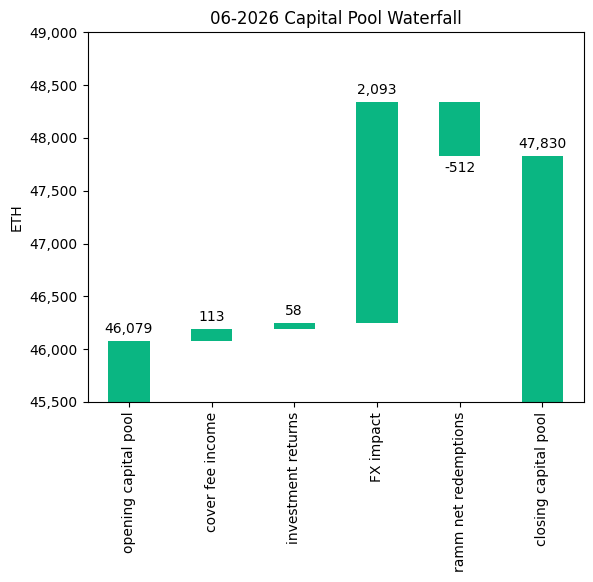

In [29]:
# waterfall chart for changes in the capital pool

# create dataframe with relevant categories
index = ['opening capital pool', 'cover fee income', 'claims', 'investment returns', 'FX impact', 'ramm net redemptions']
data = {'amount': [total_cap_monthly_opening, monthly_cover_fees, monthly_claims, total_monthly_inv_earnings, fx_change, ramm_flow_monthly_eth_change]}
df_waterfall = pd.DataFrame(data=data, index=index)
if monthly_claims == 0:
    df_waterfall = df_waterfall.drop('claims')

# close on the actual pool; whatever the items don't explain is shown, not hidden
total_eth = total_cap_monthly_closing
unallocated_eth = total_eth - df_waterfall['amount'].sum()
# bar dropped when it would label as "0" on the chart (labels are whole ETH); the value is still printed
unallocated_display_threshold = 0.5
if abs(unallocated_eth) >= unallocated_display_threshold:
    df_waterfall.loc['unallocated'] = unallocated_eth

# create a shifted dataframe by one space and fill the empty space with zero
df_shift = df_waterfall.amount.cumsum().shift(1).fillna(0)

# add the 'closing' line to both dataframes
df_waterfall.loc['closing capital pool'] = total_eth
df_shift.loc['closing capital pool'] = 0

# auto-compute y-axis limits
# relevant y-values: tops/bottoms of change bars + opening/closing pool values
# (excludes the 0 base of opening and closing bars to keep the chart zoomed in)
intermediate_bottoms = df_shift.values[1:-1]
intermediate_tops = (df_shift + df_waterfall['amount']).values[1:-1]
relevant_y = np.concatenate([intermediate_bottoms, intermediate_tops,
                              [total_cap_monthly_opening, total_eth]])
y_min, y_max = relevant_y.min(), relevant_y.max()
padding = (y_max - y_min) * 0.25
bottom = y_min - padding
top = y_max + padding

# define the Nexus Mutual green color
color = '#0AB682'

# create waterfall plot
waterfall_plot = df_waterfall.plot.bar(
    stacked=True, bottom=df_shift, legend=None, color=color,
    title=f'{valn_date_str[-7:]} Capital Pool Waterfall'
)
waterfall_plot.set_ylim(bottom=bottom, top=top)
waterfall_plot.set_ylabel('ETH')

# change format of tick values
tick_vals = waterfall_plot.get_yticks()
waterfall_plot.set_yticks(tick_vals)
waterfall_plot.set_yticklabels([f'{x:,.0f}' for x in tick_vals])

# label loop for individual items
# offsets scaled to visible data range so labels sit just above/below bar tips
neg_offset = (y_max - y_min) / 15
pos_offset = (y_max - y_min) / 30

y_height = df_shift

for loop, (index, row) in enumerate(df_waterfall.iterrows()):
    y = y_height.iloc[loop] + row['amount']
    # determine negative or positive offset
    if row['amount'] > 0:
        y += pos_offset
    else:
        y -= neg_offset
    waterfall_plot.annotate(f"{row['amount']:,.0f}", (loop, y), ha="center")

In [30]:
# unallocated by asset: actual change in each df_cap column less what the waterfall booked to it
o = df_cap.loc[df_cap['day'] == eom_before_valn_date].iloc[0]
c = df_cap.loc[df_cap['day'] == valn_date].iloc[0]
sales = sum(stETH_sale_amounts) + sum(rETH_sale_amounts)
booked = {
    'ETH': monthly_cover_fees_eth + claims_eth + ramm_flow_monthly_eth_change + sales + member_fees_eth + claim_deposits_eth,
    'USDC': usdc_fx_change + monthly_cover_fees_usdc_in_eth + claims_usdc_in_eth + claim_recoveries_in_eth,
    'Cover Re': cover_re_fx_change,
    'cbBTC': cbbtc_fx_change + monthly_cover_fees_cbbtc_in_eth + claims_cbbtc_in_eth,
    'stETH': stETH_monthly_return - sum(stETH_sale_amounts),
    'rETH': rETH_monthly_return - sum(rETH_sale_amounts),
    'Enzyme': Enzyme_monthly_return,
}
df_unalloc = pd.DataFrame({'actual change': {k: c[k] - o[k] for k in booked}, 'booked': booked})
df_unalloc['unallocated'] = df_unalloc['actual change'] - df_unalloc['booked']
print(df_unalloc)
print(f"Assets = {df_unalloc['unallocated'].sum():,.4f} | member fees + claim deposits = {member_fees_eth + claim_deposits_eth:,.4f} "
      f"| waterfall unallocated = {unallocated_eth:,.4f}")

          actual change  booked  unallocated
ETH             -508.82 -508.82        -0.00
USDC             545.91  545.91         0.00
Cover Re        1651.70 1651.70        -0.00
cbBTC              4.66    4.66        -0.00
stETH             23.44   23.44         0.00
rETH              11.92   11.92         0.00
Enzyme            22.52   22.52         0.00
Assets = -0.0000 | member fees + claim deposits = 0.0260 | waterfall unallocated = 0.0262


In [31]:
# NXM supply
df_nxm_supply = nxm_supply_result
# change day to a datetime, and remove timezone
df_nxm_supply['block_date'] = pd.to_datetime(df_nxm_supply['block_date']).dt.tz_localize(None)
nxm_supply_monthly_opening = df_nxm_supply.loc[df_nxm_supply['block_date'] == eom_before_valn_date]['total_nxm'].values[0]
nxm_supply_monthly_closing = df_nxm_supply.loc[df_nxm_supply['block_date'] == valn_date]['total_nxm'].values[0]
nxm_supply_monthly_change = abs(nxm_supply_monthly_closing - nxm_supply_monthly_opening)
print(f'NXM supply opening = {nxm_supply_monthly_opening:,.4f}')
print(f'NXM supply closing = {nxm_supply_monthly_closing:,.4f}')
print(f'NXM supply change = {nxm_supply_monthly_change:,.4f}')

NXM supply opening = 1,734,379.4513
NXM supply closing = 1,717,196.4101
NXM supply change = 17,183.0412


In [32]:
nxm_supply_result[(nxm_supply_result['block_date'] > eom_before_valn_date) & (nxm_supply_result['block_date']<=valn_date)]

,block_date,nxm_mint,nxm_burn,total_nxm_mint,total_nxm_burn,total_nxm
86,2026-06-30,72.31,-85.33,13662624.20,-11945427.79,1717196.41
87,2026-06-29,6.24,-1951.40,13662551.88,-11945342.46,1717209.42
88,2026-06-28,2.48,-99.36,13662545.64,-11943391.06,1719154.58
89,2026-06-27,0.81,-53.48,13662543.17,-11943291.70,1719251.47
90,2026-06-26,1.57,-17.92,13662542.36,-11943238.22,1719304.14
91,2026-06-25,85.38,-5.28,13662540.78,-11943220.30,1719320.48
92,2026-06-24,52.89,-2039.67,13662455.41,-11943215.02,1719240.38
93,2026-06-23,0.11,-2029.86,13662402.52,-11941175.36,1721227.16
94,2026-06-22,425.94,-198.02,13662402.41,-11939145.50,1723256.91
95,2026-06-21,2.51,-126.93,13661976.47,-11938947.48,1723028.99


### Changes in the capital pool as a book value per NXM value

Book value (BV) per NXM = Capital Pool (ETH) / NXM supply. The waterfall is an exact daily chain: each day, BV change = (ETH change − previous day's BV × NXM change) / NXM at day end, summed over the month.

1. Opening BV = Opening Capital Pool / NXM at start of month
2. Cover fee income = ETH value of premiums received (ETH, USDC, cbBTC), net of commission
3. Cover-related mints and burns = all NXM minted or burned outside the RAMM, valued at the previous day's BV: staking rewards minted on cover buys and edits (dilution), less unearned rewards burned on edits, NXM-paid premiums burned and stake burned for claims
4. Claims = ETH paid out net of recoveries (shown only when there are claims)
5. Investment returns and 6. FX impact = ETH change from each
7. Value add from RAMM = ETH paid out less the BV of NXM burned (and the reverse for mints): positive when redemptions are below BV
8. Unallocated = other ETH (membership fees, claim deposits); hidden when below 0.0005 per 1000 NXM
9. Closing BV = Closing Capital Pool / NXM at end of month

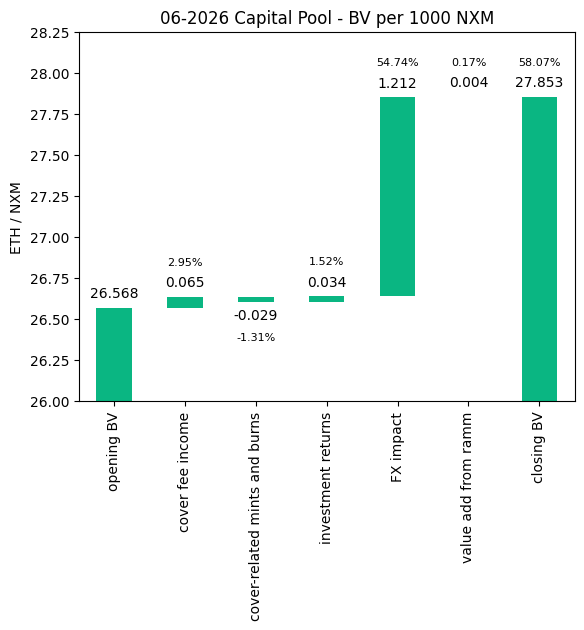

In [33]:
# waterfall chart for changes in the capital pool as a book value per NXM value
# exact daily chain: BV change on day t = (ETH change_t - BV_{t-1} x NXM change_t) / NXM_t, summed over the month
# ETH changes are split by cause; NXM changes are valued at the previous day's BV

factor = 1000
days = pd.date_range(eom_before_valn_date, valn_date, freq='D')

# pool value (ETH) and NXM supply at each day end
cap_d = df_cap.set_index('day').reindex(days)
pool_d = cap_d['sum']
nxm_d = df_nxm_supply.set_index('block_date').reindex(days)
bv_prev = (pool_d / nxm_d['total_nxm']).shift(1)

# ETH changes by cause
flows_d = df_flows.set_index('block_date').reindex(days).fillna(0)
fees_d = flows_d['premium_eth'] + flows_d['premium_usdc_eth'] + flows_d['premium_cbbtc_eth']
claims_d = flows_d['claim_eth'] + flows_d['claim_usdc_eth'] + flows_d['claim_cbbtc_eth'] + flows_d['claim_recovery_usdc_eth']
fx_d = flows_d['fx_usdc_eth'] + flows_d['fx_cover_re_eth'] + flows_d['fx_cbbtc_eth']
sales_d = pd.Series(0.0, index=days)
for d, amt in stETH_sales + rETH_sales:
    sales_d[datetime.strptime(d, '%d-%m-%Y')] += amt
inv_d = (cap_d['stETH'] + cap_d['rETH'] + cap_d['Enzyme']).diff() + sales_d   # sale proceeds added back, as in the monthly returns
ramm_cum = df_ramm.set_index('block_date').sort_index()
ramm_cum = ramm_cum.reindex(pd.date_range(ramm_cum.index.min(), valn_date, freq='D')).ffill().reindex(days)   # no row on days without trades
ramm_eth_d = (ramm_cum['cummulative_eth_in'] - ramm_cum['cummulative_eth_out']).diff()
other_eth_d = pool_d.diff() - (fees_d + claims_d + fx_d + inv_d + ramm_eth_d)   # membership fees, claim deposits

# NXM changes by cause
ramm_nxm_d = ramm_cum['cummulative_nxm_out'].diff() - ramm_cum['cummulative_nxm_in'].diff()   # minted to RAMM buyers less burned by redeemers
# everything else: staking rewards minted on cover buys/edits, unearned rewards burned on edits, NXM-paid premiums burned, stake burned for claims
cover_nxm_d = nxm_d['nxm_mint'] + nxm_d['nxm_burn'] - ramm_nxm_d

# contribution of each cause to BV per 1000 NXM
bv_contrib = pd.DataFrame({
    'cover fee income': fees_d,
    'cover-related mints and burns': -bv_prev * cover_nxm_d,
    'claims': claims_d,
    'investment returns': inv_d,
    'FX impact': fx_d,
    'value add from ramm': ramm_eth_d - bv_prev * ramm_nxm_d,
    'unallocated': other_eth_d,
}).div(nxm_d['total_nxm'], axis=0).iloc[1:] * factor
bv_items = bv_contrib.sum()

opening_bv = total_cap_monthly_opening / nxm_supply_monthly_opening * factor
closing_nxm = total_eth / nxm_supply_monthly_closing * factor   # based on: Ending Capital Pool / Ending NXM
assert abs(opening_bv + bv_items.sum() - closing_nxm) < 1e-9, 'BV bridge does not close'

# create dataframe with relevant categories
df_waterfall_nxm = pd.concat([pd.Series({'opening BV': opening_bv}), bv_items]).to_frame('amount')
if monthly_claims == 0:
    df_waterfall_nxm = df_waterfall_nxm.drop('claims')
# bar dropped when it would label as "0.000" on the chart; the value is still printed in the calc steps
unallocated_nxm = bv_items['unallocated']
unallocated_nxm_display_threshold = 0.0005
if abs(unallocated_nxm) < unallocated_nxm_display_threshold:
    df_waterfall_nxm = df_waterfall_nxm.drop('unallocated')

# create a shifted dataframe by one space and fill the empty space with zero
df_shift_nxm = df_waterfall_nxm.amount.cumsum().shift(1).fillna(0)

df_waterfall_nxm.loc['closing BV'] = closing_nxm
df_shift_nxm.loc['closing BV'] = 0

# auto-compute y-axis limits
intermediate_bottoms = df_shift_nxm.values[1:-1]
intermediate_tops = (df_shift_nxm + df_waterfall_nxm['amount']).values[1:-1]
opening_bv_value = df_waterfall_nxm.loc['opening BV', 'amount']
relevant_y = np.concatenate([intermediate_bottoms, intermediate_tops,
                              [opening_bv_value, closing_nxm]])
y_min, y_max = relevant_y.min(), relevant_y.max()
padding = (y_max - y_min) * 0.25
bottom = y_min - padding
top = y_max + padding

# define the Nexus Mutual green color
color = '#0AB682'

# create waterfall plot
waterfall_plot_nxm = df_waterfall_nxm['amount'].plot(
    kind='bar', stacked=True, bottom=df_shift_nxm, legend=None, color=color,
    title=f'{valn_date_str[-7:]} Capital Pool - BV per 1000 NXM'
)
waterfall_plot_nxm.set_ylim(bottom=bottom, top=top)
waterfall_plot_nxm.set_ylabel('ETH / NXM')

# change format of tick values
tick_vals = waterfall_plot_nxm.get_yticks()
waterfall_plot_nxm.set_yticks(tick_vals)
waterfall_plot_nxm.set_yticklabels([f'{x:.2f}' for x in tick_vals])

# label loop for individual items
# offsets scaled to visible data range so labels sit just outside bar tips
# % yield label stacks further away from the bar than the value label
pos_offset = (y_max - y_min) / 20
neg_offset = (y_max - y_min) / 12
line_gap = (y_max - y_min) / 10

y_height = df_shift_nxm

opening_value = df_waterfall_nxm.loc['opening BV', 'amount']

for i, (label, row) in enumerate(df_waterfall_nxm.iterrows()):
    bar_value = row['amount']
    cumulative = df_shift_nxm.iloc[i] + bar_value

    if bar_value > 0:
        y_main = cumulative + pos_offset
        y_yield = y_main + line_gap   # % stacks above value label, away from bar
    else:
        y_main = cumulative - neg_offset
        y_yield = y_main - line_gap   # % stacks below value label, away from bar

    waterfall_plot_nxm.annotate(f"{bar_value:.3f}", (i, y_main), ha="center")

    if label == 'opening BV':
        continue
    if label == 'closing BV':
        yield_val = ((bar_value / opening_value) - 1) * 12 * 100
    else:
        yield_val = (bar_value / opening_value) * 12 * 100

    waterfall_plot_nxm.annotate(f"{yield_val:.2f}%", (i, y_yield), ha="center", fontsize=8)

In [34]:
df_waterfall

,amount
opening capital pool,46078.53
cover fee income,112.68
investment returns,57.88
FX impact,2092.62
ramm net redemptions,-511.87
closing capital pool,47829.86


In [35]:
df_waterfall_nxm

,amount
opening BV,26.57
cover fee income,0.07
cover-related mints and burns,-0.03
investment returns,0.03
FX impact,1.21
value add from ramm,0.00
closing BV,27.85


In [36]:
# calc steps

print('Method: exact daily chain. Each day, BV change = (ETH change - previous day BV x NXM change) / NXM at day end.')
print("ETH changes are split by cause, NXM changes are valued at the previous day's BV, and the daily amounts are summed over the month.")
print()

print('1. Opening Book Value per NXM = Opening Capital Pool / NXM at start of month')
print(
  f'   Opening Capital Pool = {total_cap_monthly_opening:,.6f}, ',
  f'NXM at start of month = {nxm_supply_monthly_opening:,.6f} -> ',
  f'Opening Book Value per NXM = {opening_bv / factor:,.6f}'
)
print()

# ETH and NXM moved by each cause over the month, and the resulting change in BV
_sum = lambda s: s.iloc[1:].sum()
df_calc_steps = pd.DataFrame({
    'ETH moved': [_sum(fees_d), 0.0, _sum(claims_d), _sum(inv_d), _sum(fx_d), _sum(ramm_eth_d), _sum(other_eth_d)],
    'NXM moved': [0.0, _sum(cover_nxm_d), 0.0, 0.0, 0.0, _sum(ramm_nxm_d), 0.0],
    'BV change per NXM': bv_items.values / factor,
}, index=bv_items.index)
print('2. Changes during the month (ETH in +, out -; NXM minted +, burned -)')
print(df_calc_steps.to_string(float_format=lambda x: f'{x:,.6f}'))
print()
print('   cover fee income: premiums received in ETH, USDC and cbBTC, net of commission (query 8827203)')
print('   cover-related mints and burns: all NXM minted or burned outside the RAMM - staking rewards minted on cover buys and edits,')
print('   less unearned rewards burned on edits, NXM-paid premiums burned and stake burned for claims')
print('   value add from ramm: ETH paid out less the BV of the NXM burned (and the reverse for mints)')
print(f'   (RAMM value-add query, valued trade by trade: {ramm_bv_monthly_eth_change:,.4f} ETH)')
print('   unallocated: other ETH (membership fees, claim deposits)')
print()

print('3. Closing Book Value per NXM = Closing Capital Pool / NXM at end of month')
print(
  f'   Closing Capital Pool = {total_eth:,.6f} (actual pool), ',
  f'NXM at end of month = {nxm_supply_monthly_closing:,.6f} -> ',
  f'Closing Book Value per NXM = {closing_nxm / factor:,.6f}'
)
print(f'   check: opening + changes = {(opening_bv + bv_items.sum()) / factor:,.6f}')

Method: exact daily chain. Each day, BV change = (ETH change - previous day BV x NXM change) / NXM at day end.
ETH changes are split by cause, NXM changes are valued at the previous day's BV, and the daily amounts are summed over the month.

1. Opening Book Value per NXM = Opening Capital Pool / NXM at start of month
   Opening Capital Pool = 46,078.534456,  NXM at start of month = 1,734,379.451251 ->  Opening Book Value per NXM = 0.026568

2. Changes during the month (ETH in +, out -; NXM minted +, burned -)
                                 ETH moved      NXM moved  BV change per NXM
cover fee income                112.676259       0.000000           0.000065
cover-related mints and burns     0.000000   1,827.166048          -0.000029
claims                            0.000000       0.000000           0.000000
investment returns               57.878187       0.000000           0.000034
FX impact                     2,092.620221       0.000000           0.001212
value add from ramm    

In [37]:
# Total change in capital pool - ETH
capital_pool_change = df_waterfall.loc['closing capital pool'].values[0] - df_waterfall.loc['opening capital pool'].values[0]
print(f'Capital Pool Total Change (ETH): {round(capital_pool_change, 2)}')
print(f'Capital Pool Percentage Change (ETH): {round(100 * capital_pool_change / (df_waterfall.loc["opening capital pool"].values[0]), 2)}%')

# Total change in capital pool - BV per NXM
capital_pool_change_nxm = df_waterfall_nxm.loc['closing BV'].values[0] - df_waterfall_nxm.loc['opening BV'].values[0]
print(f'Book Value Total Change (ETH per 1000 NXM): {round(capital_pool_change_nxm, 6)}')
print(f'Book Value Percentage Change (ETH per 1000 NXM): {round(100 * capital_pool_change_nxm / (df_waterfall_nxm.loc["opening BV"].values[0]), 2)}%')

Capital Pool Total Change (ETH): 1751.33
Capital Pool Percentage Change (ETH): 3.8%
Book Value Total Change (ETH per 1000 NXM): 1.285725
Book Value Percentage Change (ETH per 1000 NXM): 4.84%


# Newsletter output

In [38]:
print('State of the Capital Pool')
print()

print(f'Capital Pool Percentage Change (ETH) = {round(100 * capital_pool_change / (df_waterfall.loc["opening capital pool"].values[0]), 2)}%')
print(f'Opening Capital Pool (ETH) = {total_cap_monthly_opening:,.2f}')
print(f'Closing Capital Pool (ETH) = {total_eth:,.2f}')
if monthly_claims != 0:
    print(f'Claims paid net of recoveries (ETH) = {monthly_claims:,.2f}')
print()

print(f'Opening Book Value per NXM = {total_cap_monthly_opening / nxm_supply_monthly_opening:,.6f}')
print(f'Closing Book Value per NXM = {closing_nxm / factor:,.6f}')
print()

if stETH_sales:
    for d, amt in stETH_sales:
        print(f'stETH Divestment (CoW Swap fill), date: {d}, WETH received = {amt:,.3f}')
if rETH_sales:
    for d, amt in rETH_sales:
        print(f'rETH Divestment (CoW Swap fill), date: {d}, WETH received = {amt:,.3f}')

State of the Capital Pool

Capital Pool Percentage Change (ETH) = 3.8%
Opening Capital Pool (ETH) = 46,078.53
Closing Capital Pool (ETH) = 47,829.86

Opening Book Value per NXM = 0.026568
Closing Book Value per NXM = 0.027853



# Divestment Plan (Out of Date; Update if Required)

## Pie Chart of Assets Today

In [39]:
today_row = df_cap.iloc[0].copy()
today_row['Kiln'] = today_row['Enzyme'] - Enzyme_idle_portion
today_row['Enzyme Idle'] = Enzyme_idle_portion
today_row = today_row.rename({
    'Cover Re': 'Cover Re Investment',
})
today_row

day                    2026-09-23 00:00:00
rate_ETH_USD                       2716.85
ETH                                3905.85
DAI                                   0.00
Enzyme                            14095.10
stETH                             11847.58
rETH                               4945.83
USDC                               3216.64
cbBTC                               122.03
Cover Re Investment                4416.18
aEthWETH                              0.00
variableDebtEthUSDC                   0.00
Aave (net)                            0.00
sum                               42549.20
Kiln                              14095.10
Enzyme Idle                              0
Name: 0, dtype: object

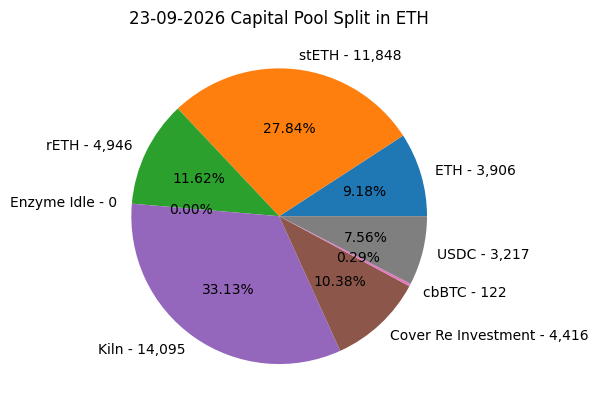

In [40]:
pie_asset_list = ['ETH', 'stETH', 'rETH', 'Enzyme Idle', 'Kiln', 'Cover Re Investment', 'cbBTC', 'USDC']
today_row_pie = today_row[pie_asset_list]

# add formatted ETH values to labels
labels = []
for n, i in enumerate(pie_asset_list):
    formatted_value = '{:,.0f}'.format(today_row_pie.values[n])
    labels.append(f'{i} - {formatted_value}')

# create chart
# extract latest date in string format
today_date_str = df_cap.iloc[0]['day'].strftime('%d-%m-%Y')
# create chart
plt.pie(today_row_pie.values, labels=labels, autopct='%1.2f%%')
plt.title(f'{today_date_str} Capital Pool Split in ETH');

## Monthly Averages Since Start of 2024 

In [41]:
# get today's day, month and year

day_today = datetime.now().day
month_today = datetime.now().month
year_today = datetime.now().year

# get eth price today
eth_usd_today = df_cap.iloc[0]['rate_ETH_USD']

# manually input average start date
averages_start_date_str = '01-08-2023'
# create average start datetime
averages_start_date = datetime.strptime(averages_start_date_str, '%d-%m-%Y')

In [42]:
import pandas as pd
from pandas.tseries.offsets import MonthBegin

# helpers
def value_on_or_before(df, day, col):
    s = df.loc[df['day'] == day, col]
    if not s.empty:
        return s.iloc[0]
    prev = df[df['day'] <= day].sort_values('day')
    return prev[col].iloc[-1] if not prev.empty else None

def ramm_net_on_or_before(day):
    prev = df_ramm[df_ramm['block_date'] <= day].sort_values('block_date')
    if prev.empty:
        return None
    last = prev.iloc[-1]
    return last['cummulative_eth_in'] - last['cummulative_eth_out']

def safe_avg(lst):
    return (sum(lst) / len(lst)) if lst else 0

# loop through months since the start date and obtain averages
date = averages_start_date.replace(day=1)
month_start_today = datetime(year_today, month_today, 1)

ramm_flows = []
net_eth_fees = []
claim_ratio = 0.7
stETH_returns = []
rETH_returns = []

while date < month_start_today:
    next_month = date + MonthBegin(1)
    
    # RAMM FLOWS (only for 2024+)
    if date.year >= 2024:
        opening = ramm_net_on_or_before(date)
        closing = ramm_net_on_or_before(next_month)
        if opening is not None and closing is not None:
            ramm_flows.append(closing - opening)
    
    # COVERS (ETH only; 15% commission out, 70% claim ratio applied)
    df_cover_flows = df_covers[(df_covers['cover_start_time'] >= date) & (df_covers['cover_start_time'] < next_month)]
    df_cover_flows = df_cover_flows[df_cover_flows['premium_asset'] == 'ETH']
    eth_cover_fees = df_cover_flows['premium_native'].sum() * 0.85
    net_eth_fees.append(eth_cover_fees * (1 - claim_ratio))
    
    # INVESTMENT INCOME (use last known value on or before dates)
    st_open = value_on_or_before(df_cap, date, 'stETH')
    st_close = value_on_or_before(df_cap, next_month, 'stETH')
    if st_open is not None and st_close is not None:
        stETH_returns.append(st_close - st_open)

    r_open = value_on_or_before(df_cap, date, 'rETH')
    r_close = value_on_or_before(df_cap, next_month, 'rETH')
    if r_open is not None and r_close is not None:
        rETH_returns.append(r_close - r_open)
    
    # move date along
    date = next_month

# Average Kiln rewards in month
days_total_kiln_rewards = (df_cap.iloc[0]['day'] - kiln_deposit_date) / timedelta(days=1)
daily_total_kiln_rewards = kiln_total_rewards / days_total_kiln_rewards
avg_monthly_kiln_returns = daily_total_kiln_rewards * avg_days_in_month

# Averages (safe if lists are empty)
avg_monthly_ramm_flows = safe_avg(ramm_flows)
avg_monthly_net_eth_fees = safe_avg(net_eth_fees)
avg_monthly_stETH_returns = safe_avg(stETH_returns)
avg_monthly_rETH_returns = safe_avg(rETH_returns)

print(f'Average monthly stETH returns = {avg_monthly_stETH_returns}')
print(f'Average monthly rETH returns = {avg_monthly_rETH_returns}')
print(f'Average monthly kiln returns = {avg_monthly_kiln_returns}')
print(f'Average monthly net ETH cover fees = {avg_monthly_net_eth_fees}')
print(f'Average monthly RAMM flows = {avg_monthly_ramm_flows}')


Average monthly stETH returns = -562.5239055938382
Average monthly rETH returns = -218.3040656926968
Average monthly kiln returns = 10.224112166455079
Average monthly net ETH cover fees = 7.429320962515352
Average monthly RAMM flows = -2061.4765856083786


## Asset Projection

In [43]:
today_row

day                    2026-09-23 00:00:00
rate_ETH_USD                       2716.85
ETH                                3905.85
DAI                                   0.00
Enzyme                            14095.10
stETH                             11847.58
rETH                               4945.83
USDC                               3216.64
cbBTC                               122.03
Cover Re Investment                4416.18
aEthWETH                              0.00
variableDebtEthUSDC                   0.00
Aave (net)                            0.00
sum                               42549.20
Kiln                              14095.10
Enzyme Idle                              0
Name: 0, dtype: object

In [44]:
proj_asset_list = ['ETH', 'stETH', 'rETH', 'Enzyme Idle', 'Kiln', 'Cover Re Investment', 'USDC']
today_row_proj = today_row[proj_asset_list]

asset_df = pd.DataFrame(today_row_proj).T

projection_months = 12
cover_re_apy = 0.2

for i in range(projection_months):
    
    next_row = {}
    next_row['ETH'] = asset_df['ETH'].values[-1] + avg_monthly_ramm_flows + avg_monthly_net_eth_fees
    next_row['USDC'] = asset_df['USDC'].values[-1]
    next_row['stETH'] = asset_df['stETH'].values[-1] + avg_monthly_stETH_returns
    next_row['rETH'] = asset_df['rETH'].values[-1] + avg_monthly_rETH_returns
    next_row['Kiln'] = asset_df['Kiln'].values[-1] + avg_monthly_kiln_returns
    next_row['Enzyme Idle'] = asset_df['Enzyme Idle'].values[-1]
    next_row['Cover Re Investment'] = asset_df['Cover Re Investment'].values[-1] * ((1 + cover_re_apy)**(1/12))
    
    asset_df.loc[len(asset_df)] = next_row

asset_df

,ETH,stETH,rETH,Enzyme Idle,Kiln,Cover Re Investment,USDC
0,3905.85,11847.58,4945.83,0,14095.10,4416.18,3216.64
1,1851.80,11285.05,4727.53,0,14105.32,4483.79,3216.64
2,-202.25,10722.53,4509.22,0,14115.55,4552.43,3216.64
3,-2256.30,10160.00,4290.92,0,14125.77,4622.13,3216.64
4,-4310.34,9597.48,4072.62,0,14136.00,4692.89,3216.64
5,-6364.39,9034.96,3854.31,0,14146.22,4764.73,3216.64
6,-8418.44,8472.43,3636.01,0,14156.45,4837.68,3216.64
7,-10472.48,7909.91,3417.70,0,14166.67,4911.74,3216.64
8,-12526.53,7347.38,3199.40,0,14176.89,4986.94,3216.64
9,-14580.58,6784.86,2981.10,0,14187.12,5063.28,3216.64


In [45]:
asset_df_6_mo = asset_df[:6].astype(float)
asset_df_6_mo_pos = asset_df_6_mo

[Text(0, -10000.0, '-10,000'),
 Text(0, -5000.0, '-5,000'),
 Text(0, 0.0, '0'),
 Text(0, 5000.0, '5,000'),
 Text(0, 10000.0, '10,000'),
 Text(0, 15000.0, '15,000'),
 Text(0, 20000.0, '20,000')]

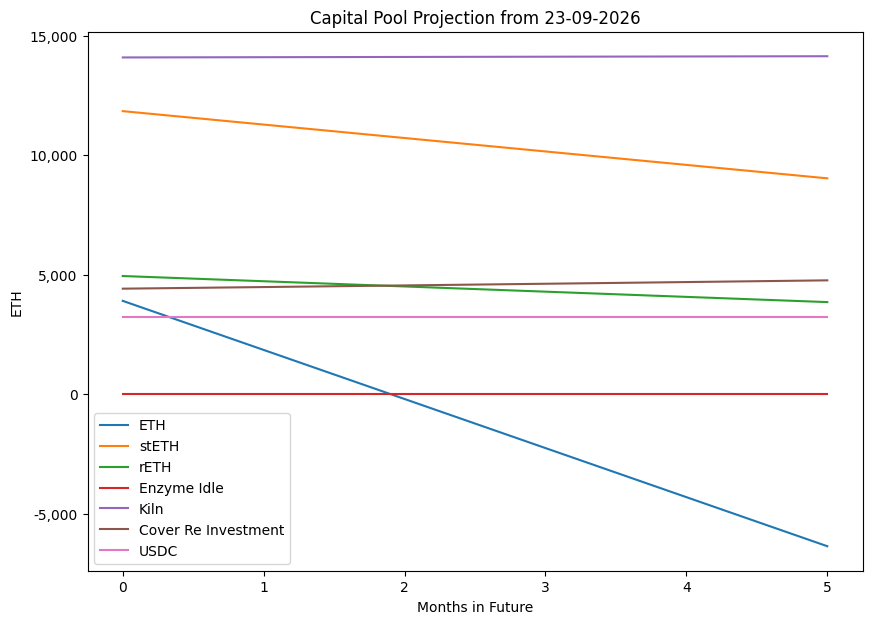

In [46]:
# Plot the data
projection_plot = asset_df_6_mo.plot(
    title=f'Capital Pool Projection from {today_date_str}',
    figsize=(10, 7),
    legend=True,
    ylabel='ETH',
    xlabel='Months in Future'
)

# Get the tick values and format them
tick_vals = projection_plot.get_yticks()
projection_plot.yaxis.set_major_locator(FixedLocator(tick_vals))
projection_plot.set_yticklabels(['{:,.0f}'.format(x) for x in tick_vals])

[Text(0, -10000.0, '-10,000'),
 Text(0, 0.0, '0'),
 Text(0, 10000.0, '10,000'),
 Text(0, 20000.0, '20,000'),
 Text(0, 30000.0, '30,000'),
 Text(0, 40000.0, '40,000'),
 Text(0, 50000.0, '50,000')]

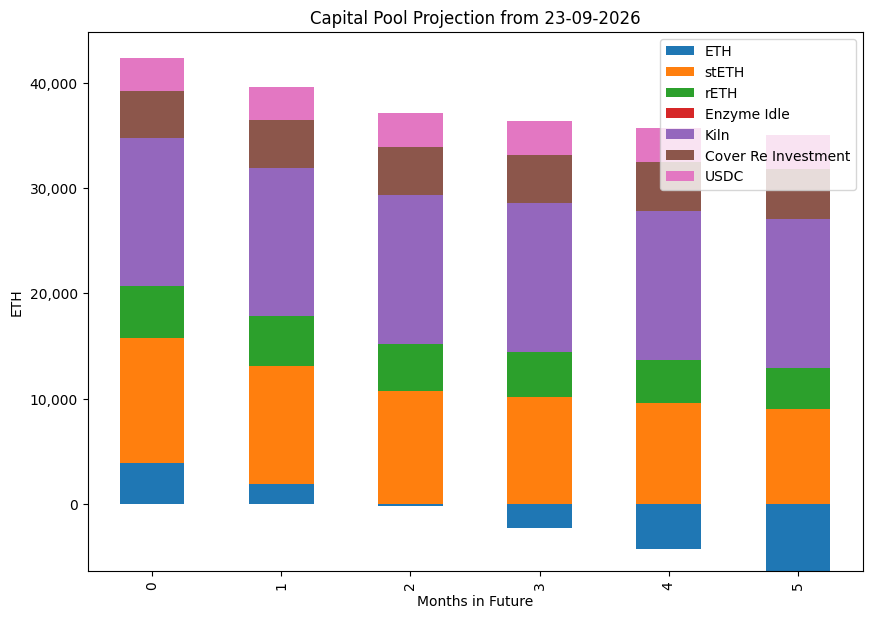

In [47]:
# Plot the data
projection_bar_plot = asset_df_6_mo_pos.plot(
    kind='bar', 
    stacked=True, 
    title=f'Capital Pool Projection from {today_date_str}',
    figsize=(10, 7), 
    legend=True, 
    ylabel='ETH', 
    xlabel='Months in Future'
)

# Fix y-ticks for the bar plot
tick_vals = projection_bar_plot.get_yticks()
projection_bar_plot.yaxis.set_major_locator(FixedLocator(tick_vals))
projection_bar_plot.set_yticklabels(['{:,.0f}'.format(x) for x in tick_vals])

In [48]:
df_sum = asset_df_6_mo_pos.sum(axis=1)
df_rel = asset_df_6_mo_pos.div(df_sum, 0)*100
df_rel

,ETH,stETH,rETH,Enzyme Idle,Kiln,Cover Re Investment,USDC
0,9.21,27.92,11.66,0.00,33.22,10.41,7.58
1,4.67,28.45,11.92,0.00,35.56,11.30,8.11
2,-0.55,29.05,12.22,0.00,38.24,12.33,8.71
3,-6.61,29.74,12.56,0.00,41.35,13.53,9.42
4,-13.72,30.56,12.97,0.00,45.01,14.94,10.24
5,-22.21,31.53,13.45,0.00,49.37,16.63,11.23


In [49]:
for n in df_rel: 
    for i, (cs, ab, pc) in enumerate(zip(asset_df_6_mo_pos.cumsum(1)[n],  
                                         asset_df_6_mo_pos[n], df_rel[n])): 
        print(cs - ab / 2, i, str(np.round(pc, 1)) + '%')

1952.92318218355 0 9.2%
925.8995498606182 1 4.7%
-101.12408246231342 2 -0.5%
-1128.1477147852452 3 -6.6%
-2155.1713471081766 4 -13.7%
-3182.194979431108 5 -22.2%
9829.634097740985 0 27.9%
7494.324880298203 1 28.4%
5159.0156628554205 2 29.0%
2823.7064454126385 3 29.7%
488.39722796985643 4 30.6%
-1846.9119894729256 5 31.5%
18226.33798358207 0 11.7%
15500.61478049602 1 11.9%
12774.89157740997 2 12.2%
10049.168374323923 3 12.6%
7323.445171237871 4 13.0%
4597.721968151822 5 13.5%
20699.25413604927 0 0.0%
17864.37890011687 1 0.0%
15029.503664184473 2 0.0%
12194.628428252076 3 0.0%
9359.753192319677 4 0.0%
6524.877956387279 5 0.0%
27746.804381972725 0 33.2%
24917.041202123553 1 35.6%
22087.278022274382 2 38.2%
19257.514842425215 3 41.4%
16427.751662576044 4 45.0%
13597.988482726872 5 49.4%
37002.44279494822 0 10.4%
34211.59633183657 1 11.3%
31421.26740017996 2 12.3%
28631.46392311093 3 13.5%
25842.19394506099 4 14.9%
23053.465633617634 5 16.6%
40818.852390224914 0 7.6%
38061.81058776755 1 8.1

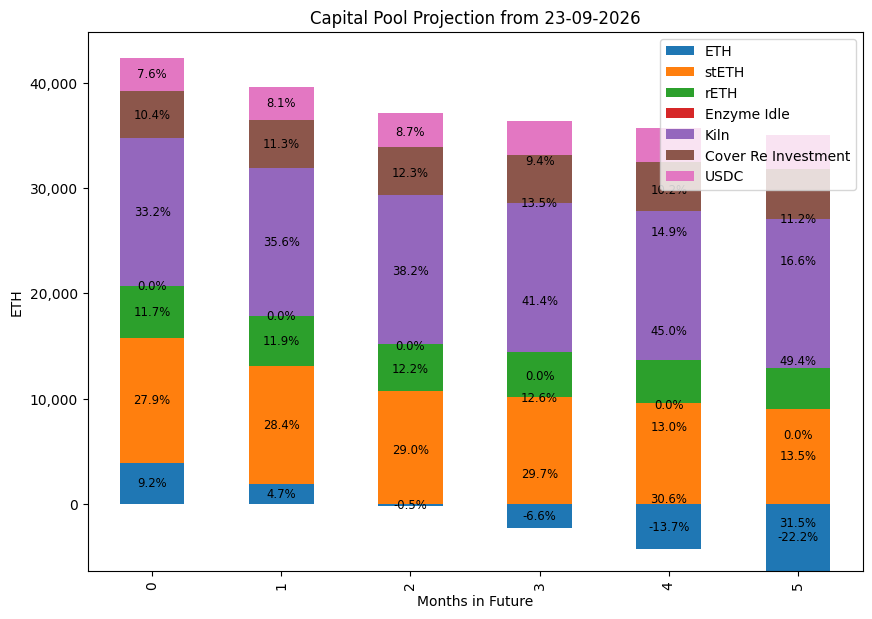

In [50]:
# Plot the data
projection_bar_perc_plot = asset_df_6_mo_pos.plot(
    kind='bar', 
    stacked=True, 
    title=f'Capital Pool Projection from {today_date_str}',
    figsize=(10, 7), 
    legend=True, 
    ylabel='ETH', 
    xlabel='Months in Future'
)

# Fix y-ticks for the bar plot
tick_vals = projection_bar_perc_plot.get_yticks()
projection_bar_perc_plot.yaxis.set_major_locator(FixedLocator(tick_vals))
projection_bar_perc_plot.set_yticklabels(['{:,.0f}'.format(x) for x in tick_vals])

# Add percentage labels
for n in df_rel: 
    for i, (cs, ab, pc) in enumerate(zip(asset_df_6_mo_pos.cumsum(1)[n],  
                                         asset_df_6_mo_pos[n], df_rel[n])): 
        projection_bar_perc_plot.text(
            y=cs - ab / 2, 
            x=i, 
            s=f'{np.round(pc, 1)}%', 
            va='center', 
            ha='center', 
            size='small'
        )